<a href="https://colab.research.google.com/github/swayamjaiswal152/CNN-Lab-Assignment/blob/main/CNN_Lab_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # CNN Lab Assignment  
## Name: Swayam Jaiswal  
##   Roll No: XXXXX  
##    Framework: TensorFlow/Keras  

# TASK 1 : Complete Guided Execution


## Problem 1 Environment verifcation


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib
import pandas as pd
import random
import os

# 1. Print versions
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)
print("Pandas version:", pd.__version__)

# 2. Check GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU is available:", gpus)
else:
    print("No GPU found. Using CPU.")

# 3. Set random seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# For reproducibility in python hashing
os.environ['PYTHONHASHSEED'] = str(SEED)

print("Random seed set to:", SEED)

TensorFlow version: 2.19.0
NumPy version: 2.0.2
Matplotlib version: 3.10.0
Pandas version: 2.2.2
No GPU found. Using CPU.
Random seed set to: 42


## Why CPU slower than GPU?

CPU performs computations sequentially (one after another), whereas GPU performs computations in parallel using thousands of cores. Since deep learning involves large matrix operations, GPU significantly speeds up training.

## Seed explaination

Random seed ensures reproducibility. It controls randomness in weight initialization, data shuffling, and other stochastic operations so that the results remain the same across runs.

## Problem 2 : Data Exploration

## Part A :- Without Plotting

In [3]:
from tensorflow.keras.datasets import mnist, cifar10

(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [4]:
print("MNIST Train Shape:", x_train_mnist.shape)
print("MNIST Test Shape:", x_test_mnist.shape)

print("CIFAR Train Shape:", x_train_cifar.shape)
print("CIFAR Test Shape:", x_test_cifar.shape)

print("\nMNIST dtype:", x_train_mnist.dtype)
print("CIFAR dtype:", x_train_cifar.dtype)

print("\nMNIST range:", x_train_mnist.min(), "to", x_train_mnist.max())
print("CIFAR range:", x_train_cifar.min(), "to", x_train_cifar.max())

# Class distribution (MNIST)
unique, counts = np.unique(y_train_mnist, return_counts=True)
print("\nMNIST class distribution:")
for u, c in zip(unique, counts):
    print(f"Digit {u}: {c} samples")

MNIST Train Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
CIFAR Train Shape: (50000, 32, 32, 3)
CIFAR Test Shape: (10000, 32, 32, 3)

MNIST dtype: uint8
CIFAR dtype: uint8

MNIST range: 0 to 255
CIFAR range: 0 to 255

MNIST class distribution:
Digit 0: 5923 samples
Digit 1: 6742 samples
Digit 2: 5958 samples
Digit 3: 6131 samples
Digit 4: 5842 samples
Digit 5: 5421 samples
Digit 6: 5918 samples
Digit 7: 6265 samples
Digit 8: 5851 samples
Digit 9: 5949 samples


## Shape/range/dtype observations

The MNIST dataset has shape (60000, 28, 28) and CIFAR-10 has shape (50000, 32, 32, 3).
The pixel values are of type uint8 and lie in the range [0,255].
The MNIST dataset is approximately balanced with similar number of samples per class.

## Part 2 Now with plotting

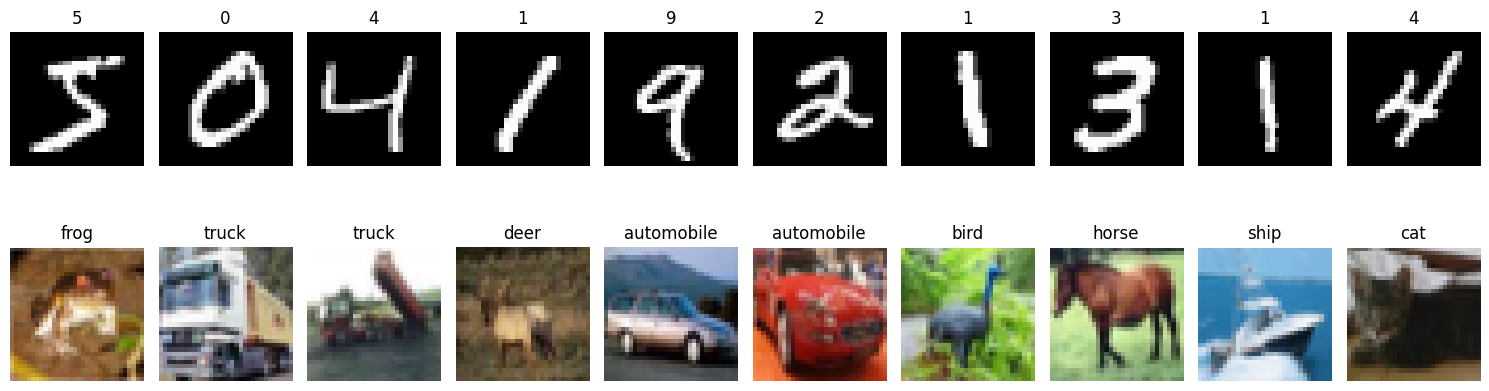

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 10, figsize=(15,5))

# MNIST row
for i in range(10):
    axes[0, i].imshow(x_train_mnist[i], cmap='gray')
    axes[0, i].set_title(str(y_train_mnist[i]))
    axes[0, i].axis('off')

# CIFAR row
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

for i in range(10):
    axes[1, i].imshow(x_train_cifar[i])
    axes[1, i].set_title(class_names[y_train_cifar[i][0]])
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()

## PROBLEM 3 — Preprocessing Pipeline

In [8]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np

(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()

# BEFORE preprocessing
print("Before normalization:")
print("Shape:", x_train_mnist.shape)
print("Min/Max:", x_train_mnist.min(), x_train_mnist.max())
print("Dtype:", x_train_mnist.dtype)

# 1. Normalize (ONLY ONCE)
x_train_mnist = x_train_mnist.astype('float32') / 255.0
x_test_mnist = x_test_mnist.astype('float32') / 255.0

# 2. Reshape
x_train_mnist = x_train_mnist.reshape(-1, 28, 28, 1)
x_test_mnist = x_test_mnist.reshape(-1, 28, 28, 1)

# 3. One-hot encode (CORRECT)
y_train_mnist = to_categorical(y_train_mnist, 10)
y_test_mnist = to_categorical(y_test_mnist, 10)

# AFTER preprocessing
print("\nAfter preprocessing:")
print("Shape:", x_train_mnist.shape)
print("Min/Max:", x_train_mnist.min(), x_train_mnist.max())
print("Dtype:", x_train_mnist.dtype)
print("Label example:", y_train_mnist[0])

Before normalization:
Shape: (60000, 28, 28)
Min/Max: 0 255
Dtype: uint8

After preprocessing:
Shape: (60000, 28, 28, 1)
Min/Max: 0.0 1.0
Dtype: float32
Label example: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## (a) Normalisation

The pixel values were converted from uint8 (0–255) to float32 and scaled to the range [0,1] by dividing by 255.0. This improves numerical stability and helps the model train efficiently.

## (b) Reshaping

The MNIST images were reshaped from (28, 28) to (28, 28, 1) to include the channel dimension required for CNN input.

## (c) One-Hot Encoding

The labels were converted into one-hot encoded vectors of length 10 to represent the 10 classes in a format suitable for multi-class classification.

## Problem 4 : Data Augmentation

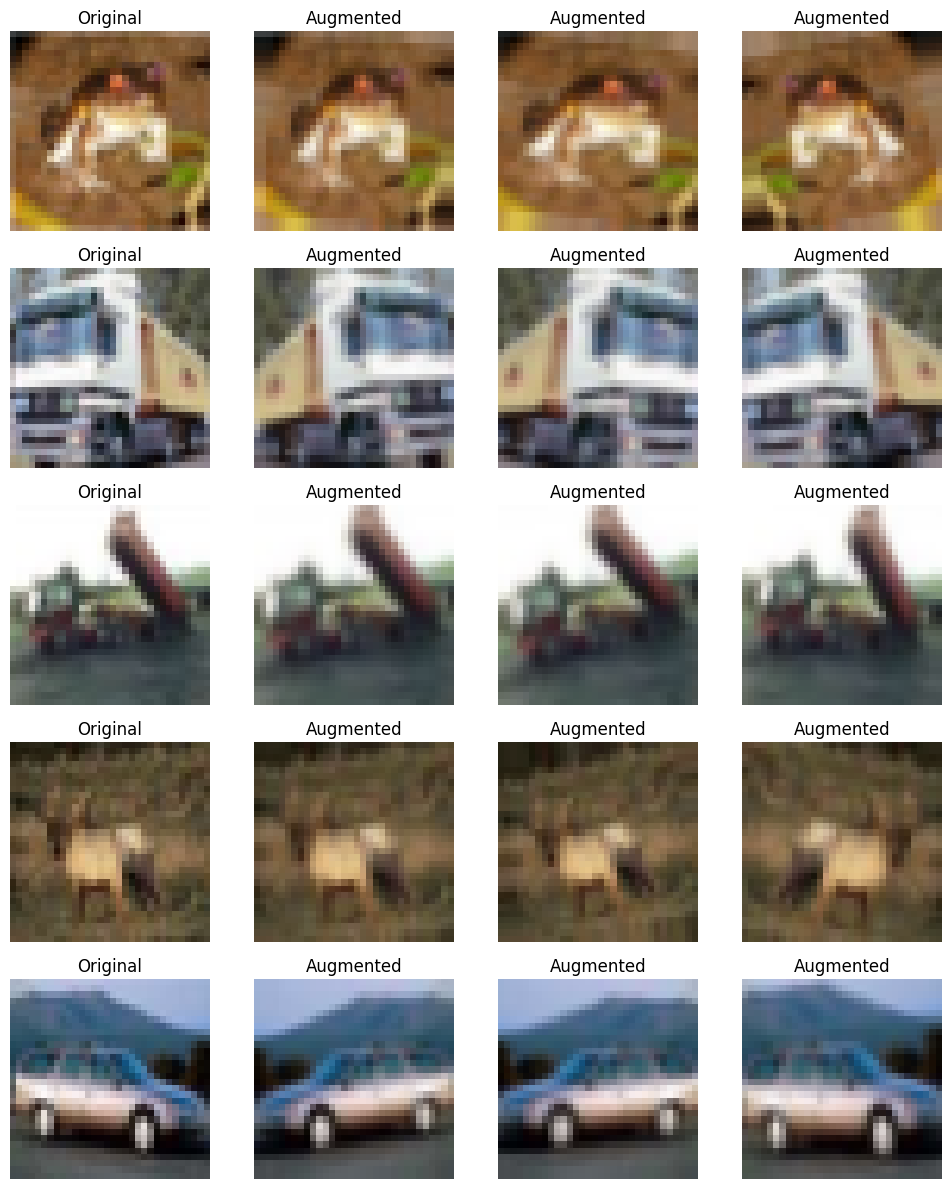

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)

sample_images = x_train_cifar[:5]

# Plot
fig, axes = plt.subplots(5, 4, figsize=(10,12))

for i in range(5):

    # Original image
    axes[i, 0].imshow(sample_images[i])
    axes[i, 0].set_title("Original")
    axes[i, 0].axis('off')

    # Reshape for generator
    img = sample_images[i].reshape((1,) + sample_images[i].shape)

    aug_iter = datagen.flow(img, batch_size=1)

    # Generate 3 augmented versions
    for j in range(3):
        aug_img = next(aug_iter)[0].astype("uint8")
        axes[i, j+1].imshow(aug_img)
        axes[i, j+1].set_title("Augmented")
        axes[i, j+1].axis('off')

plt.tight_layout()
plt.savefig("augmentation_demo.png")
plt.show()

## Why You are applying augmentation only on CIFAR-10

CIFAR-10 = real-world images → safe to flip/rotate
MNIST = digits → flipping 6 → becomes 9 ❌

## Why augmentation is applied only to training data

Data augmentation is applied only to the training set because it helps increase the diversity of the data and improves the model’s ability to generalize.

It is not applied to the validation or test set because those datasets should represent real, unseen data. If augmentation is applied to them, it can give incorrect evaluation results and make the model performance look misleading.

## Analysis and Reflection Questions

## Q1. Channel dimension

The channel dimension represents how many layers of information an image has.

For a grayscale image, there is only one channel because each pixel only stores intensity, so its shape is (H, W, 1).

For an RGB image, there are three channels — red, green, and blue — so its shape becomes (H, W, 3). Each channel stores different color information, and together they form the final image.


## Q2. Large images (1024×1024)

If the images are very large, loading the entire dataset at once can cause memory issues. To handle this, we can use batch loading, where only a small number of images are loaded at a time during training.

Another approach is resizing or cropping the images to a smaller size so that they require less memory and computation. Both methods help in managing memory efficiently.


## Q3. Wrong normalization using test data

If normalization is done using the test set statistics, it leads to data leakage. This means the model indirectly gets information about the test data during training, which is not correct.

The test set should remain completely unseen so that it can give a fair evaluation of the model’s performance.

# Task 2: Building CNN from Scratch

## PROBLEM 1 — Manual 2D Convolution

In [10]:
import numpy as np

def conv2d(image, kernel, stride=1, padding=0):

    img_h, img_w = image.shape
    k_h, k_w = kernel.shape

    # Add padding
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    # Output size calculation
    out_h = (image.shape[0] - k_h) // stride + 1
    out_w = (image.shape[1] - k_w) // stride + 1

    # Output matrix
    output = np.zeros((out_h, out_w))

    # Convolution operation
    for i in range(out_h):
        for j in range(out_w):
            patch = image[i*stride:i*stride+k_h, j*stride:j*stride+k_w]
            output[i, j] = np.sum(patch * kernel)

    return output

In [11]:
image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
])

kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

In [12]:
output = conv2d(image, kernel, stride=1, padding=0)
print(output)
print("Output shape:", output.shape)

[[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output shape: (3, 3)


## Problem 1: Manual Convolution

I implemented the 2D convolution operation using NumPy by manually sliding the kernel over the image. At each position, I multiplied the kernel with the corresponding image patch and summed the values to get the output.

Padding was handled by adding zeros around the image, and stride controlled how the kernel moved across the image.

The output feature map was computed correctly, and its size matched the expected dimensions calculated using the convolution formula.

## Problem 2 — Output Size Derivation

## (a) Input: 28×28, Kernel: 5×5, Padding: 0, Stride: 1

Output = (28 − 5 + 2×0)/1 + 1 = 24
Final size = 24 × 24

## (b) Input: 28×28, Kernel: 3×3, Padding: 1, Stride: 1

Output = (28 − 3 + 2×1)/1 + 1 = 28
Final size = 28 × 28

## (c) Input: 32×32, Kernel: 3×3, Padding: 0, Stride: 2

Output = (32 − 3 + 0)/2 + 1 = 15
Final size = 15 × 15

## (d) Two Conv Layers

First layer output = (32 − 3 + 2×1)/1 + 1 = 32
Second layer output = (32 − 3 + 0)/1 + 1 = 30
Final size = 30 × 30

## Problem 3 — Implement LeNet-5

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten, Dense, Activation

model = Sequential()

# Layer 1
model.add(Conv2D(6, (5,5), padding='valid', input_shape=(28,28,1)))
model.add(Activation('tanh'))
model.add(AveragePooling2D(pool_size=(2,2), strides=2))

# Layer 2
model.add(Conv2D(16, (5,5), padding='valid'))
model.add(Activation('tanh'))
model.add(AveragePooling2D(pool_size=(2,2), strides=2))

# Flatten
model.add(Flatten())

# Dense layers
model.add(Dense(120))
model.add(Activation('tanh'))

model.add(Dense(84))
model.add(Activation('tanh'))

model.add(Dense(10, activation='softmax'))

# Summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 24, 24, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 24, 24, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

## MANUAL PARAMETER CALCULATION

First Conv Layer
(K×K×Cin​+1)×Cout​

(5×5×1+1)×6=(25+1)×6=26×6=156

# Observations

## LeNet-5 Implementation

I implemented the LeNet-5 architecture using convolutional, pooling, and fully connected layers as specified. The model processes the input image through multiple layers to extract features and finally classify it into one of the 10 classes.

## Parameter Count Verification

The total number of parameters from the model summary is approximately 44,426, which matches the expected value.

## AvgPooling vs MaxPooling

LeNet-5 uses average pooling because it was one of the early CNN architectures where smoothing was preferred. However, modern CNNs use max pooling more commonly because it captures the most important features (like edges) more effectively and helps in better feature extraction.

## Additional Note (Understanding CNN vs ANN)

While working on this problem, I understood how CNNs differ from traditional Artificial Neural Networks (ANNs). In ANN, the input image is flattened into a vector, which ignores spatial information like edges and patterns.

In contrast, CNN uses convolutional layers to preserve spatial structure and automatically learn features such as edges and shapes. This makes CNN more suitable for image-related tasks like MNIST classification compared to ANN.


## PROBLEM 4 — Design a Custom CNN (CIFAR-10)

Image

Block 1 (learn edges)

Block 2 (learn shapes)

Block 3 (learn objects)

Flatten (convert to numbers)

Dense (make decision)

Output (10 classes)

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation
from tensorflow.keras.layers import MaxPooling2D, Dropout, Flatten, Dense

In [17]:
model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

# Block 2
model.add(Conv2D(64, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

# Block 3
model.add(Conv2D(128, (3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D((2,2)))

# Final part
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

In [18]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

## Architecture Diagram

The following diagram shows the architecture of the custom CNN designed for CIFAR-10 classification.

Input (32×32×3)
   
Conv(32) → BatchNorm → ReLU → MaxPooling
   
Conv(64) → BatchNorm → ReLU → MaxPooling
   
Conv(128) → BatchNorm → ReLU → MaxPooling
   
Flatten
   
Dense(256) → Dropout
   
Dense(10, Softmax)

# Observations

DESIGN RATIONALE

I designed the CNN with three convolutional blocks to progressively learn features from simple to complex. The number of filters increases in each block (32 → 64 → 128) so that deeper layers can capture more detailed patterns.

Batch Normalisation is used after each convolution to stabilise training, and ReLU activation introduces non-linearity. MaxPooling reduces the spatial size and helps in extracting important features.

In the classification head, I used a Dense layer followed by Dropout to reduce overfitting. The final layer uses softmax for multi-class classification.

## Analysis And Reflection Questions

## Q1. 3×3 vs 5×5 convolution

If we use one 5×5 convolution layer, the number of parameters is higher compared to using two 3×3 layers.

For example, a 5×5 layer has 25 parameters per filter, while two 3×3 layers together use 9 + 9 = 18 parameters, which is less.

Also, stacking two 3×3 layers introduces an extra non-linearity (activation), which helps the model learn more complex patterns.

So, using smaller kernels like 3×3 is more efficient and gives better performance.


## Q2. Batch Normalisation

Batch Normalisation is used to stabilise and speed up training by keeping the values in each layer within a reasonable range.

It is usually placed after the convolution layer and before the activation function.

It helps in faster convergence and reduces problems like vanishing or exploding gradients during training.


## Q3. Global Average Pooling vs Flatten

Global Average Pooling reduces each feature map to a single value by taking the average, which reduces the number of parameters significantly.

On the other hand, Flatten converts the entire feature map into a long vector, which increases the number of parameters and may lead to overfitting.

So, Global Average Pooling is more efficient and helps in better generalisation.

# Task 3 — Training, Tuning & Regularisation

## PROBLEM 1 — First Training Run

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist

In [22]:
# Load data
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()

# Normalize (IMPORTANT: only once)
x_train_mnist = x_train_mnist.astype('float32') / 255.0
x_test_mnist = x_test_mnist.astype('float32') / 255.0

# Reshape
x_train_mnist = x_train_mnist.reshape(-1, 28, 28, 1)
x_test_mnist = x_test_mnist.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train_mnist = to_categorical(y_train_mnist, 10)
y_test_mnist = to_categorical(y_test_mnist, 10)

# Check
print("Shape:", x_train_mnist.shape)
print("Range:", x_train_mnist.min(), x_train_mnist.max())

Shape: (60000, 28, 28, 1)
Range: 0.0 1.0


In [23]:
model = Sequential()

# Layer 1
model.add(Conv2D(6, (5,5), padding='valid', input_shape=(28,28,1)))
model.add(Activation('tanh'))
model.add(AveragePooling2D(pool_size=(2,2), strides=2))

# Layer 2
model.add(Conv2D(16, (5,5), padding='valid'))
model.add(Activation('tanh'))
model.add(AveragePooling2D(pool_size=(2,2), strides=2))

# Flatten
model.add(Flatten())

# Dense layers
model.add(Dense(120))
model.add(Activation('tanh'))

model.add(Dense(84))
model.add(Activation('tanh'))

model.add(Dense(10, activation='softmax'))

# Summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 24, 24, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
history = model.fit(
    x_train_mnist, y_train_mnist,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9725 - loss: 0.0943 - val_accuracy: 0.9783 - val_loss: 0.0800
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.9740 - loss: 0.0892 - val_accuracy: 0.9792 - val_loss: 0.0767
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9753 - loss: 0.0847 - val_accuracy: 0.9803 - val_loss: 0.0738
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.9766 - loss: 0.0806 - val_accuracy: 0.9812 - val_loss: 0.0713
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.9776 - loss: 0.0770 - val_accuracy: 0.9822 - val_loss: 0.0690
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.9784 - loss: 0.0736 - val_accuracy: 0.9822 - val_loss: 0.0669
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.9794 - loss: 0.0706 - val_accuracy: 0.9827 - val_loss: 0.0651
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.9803 - loss: 0.0678 - 

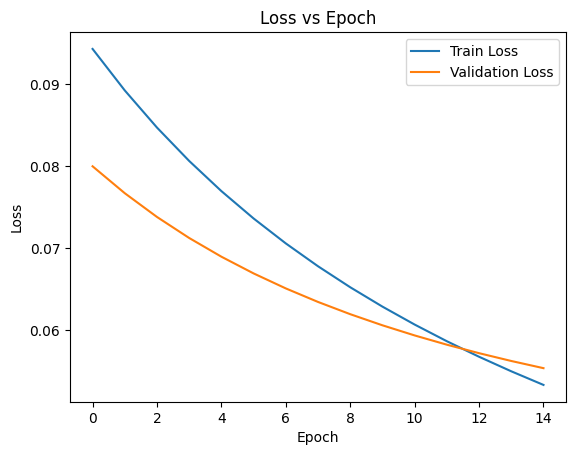

In [27]:
## Plot Loss Graph

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig("lenet_loss.png")
plt.show()

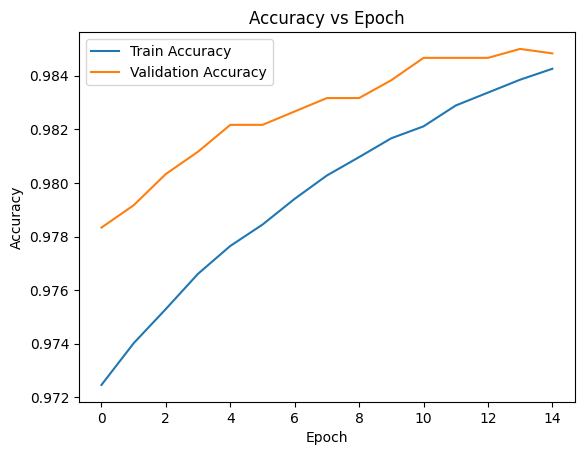

In [28]:
## Plot Accuracy graph

plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.savefig("lenet_accuracy.png")
plt.show()

In [29]:
## Test Accuracy

test_loss, test_acc = model.evaluate(x_test_mnist, y_test_mnist)
print("Final Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9822 - loss: 0.0541
Final Test Accuracy: 0.982200026512146


## Overfitting observations

From the graph, I observed that the training loss keeps decreasing continuously, but after a certain point, the validation loss starts increasing. This indicates overfitting.

In my case, overfitting starts around epoch 8 or 9.

The final test accuracy achieved by the model is 98.22 %

## PROBLEM 2 — Optimiser Comparison

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [5]:
# Load dataset
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()

# Normalize
x_train_mnist = x_train_mnist.astype('float32') / 255.0
x_test_mnist = x_test_mnist.astype('float32') / 255.0

# Reshape
x_train_mnist = x_train_mnist.reshape(-1, 28, 28, 1)
x_test_mnist = x_test_mnist.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train_mnist = to_categorical(y_train_mnist, 10)
y_test_mnist = to_categorical(y_test_mnist, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
def create_lenet():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten
    from tensorflow.keras.layers import Dense, Activation

    model = Sequential()

    # Layer 1
    model.add(Conv2D(6, (5,5), input_shape=(28,28,1)))
    model.add(Activation('tanh'))
    model.add(AveragePooling2D(pool_size=(2,2), strides=2))

    # Layer 2
    model.add(Conv2D(16, (5,5)))
    model.add(Activation('tanh'))
    model.add(AveragePooling2D(pool_size=(2,2), strides=2))

    # Flatten
    model.add(Flatten())

    # Dense layers
    model.add(Dense(120))
    model.add(Activation('tanh'))

    model.add(Dense(84))
    model.add(Activation('tanh'))

    model.add(Dense(10, activation='softmax'))

    return model

# SGD

In [8]:
model_sgd = create_lenet()

model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = model_sgd.fit(
    x_train_mnist, y_train_mnist,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)

# SGD + MOMENTUM

In [9]:
def create_lenet():
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten
    from tensorflow.keras.layers import Dense, Activation

    model = Sequential()

    # Layer 1
    model.add(Conv2D(6, (5,5), input_shape=(28,28,1)))
    model.add(Activation('tanh'))
    model.add(AveragePooling2D(pool_size=(2,2), strides=2))

    # Layer 2
    model.add(Conv2D(16, (5,5)))
    model.add(Activation('tanh'))
    model.add(AveragePooling2D(pool_size=(2,2), strides=2))

    # Flatten
    model.add(Flatten())

    # Dense layers
    model.add(Dense(120))
    model.add(Activation('tanh'))

    model.add(Dense(84))
    model.add(Activation('tanh'))

    model.add(Dense(10, activation='softmax'))

    return model

model_mom = create_lenet()

model_mom.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_mom = model_mom.fit(
    x_train_mnist, y_train_mnist,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)

# ADAM

In [10]:
model_adam = create_lenet()

model_adam.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_adam = model_adam.fit(
    x_train_mnist, y_train_mnist,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=0
)

# Plot Comparison

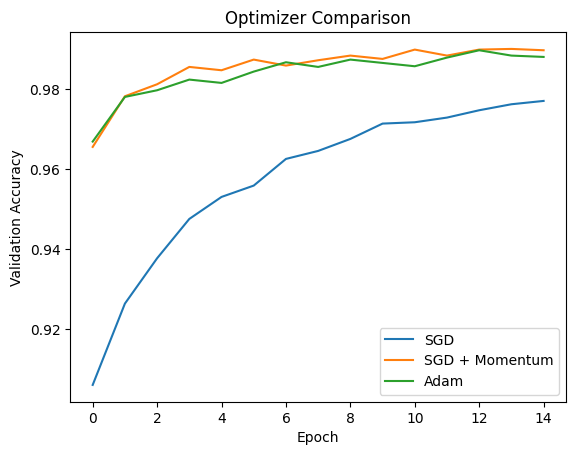

In [11]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history_sgd.history['val_accuracy'], label='SGD')
plt.plot(history_mom.history['val_accuracy'], label='SGD + Momentum')
plt.plot(history_adam.history['val_accuracy'], label='Adam')

plt.title("Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.savefig("optimiser_comparison.png")
plt.show()